In [48]:
import pandas as pd
# DATA_PATH = "/home/jovyan/work/ner_congressional_records/DATA/"
import re
from collections import Counter
from nltk.corpus import stopwords, names
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import nltk
nltk.download('stopwords')
nltk.download('names')

stop_words = set(stopwords.words('english'))
unwanted_titles = {'mr', 'mrs', 'ms', 'dr', 'jr', 'sr', 'miss', 'rev'}
human_name_list = set(name.lower() for name in names.words())
df = pd.read_csv('/content/test — копия.csv')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package names to /root/nltk_data...
[nltk_data]   Package names is already up-to-date!


In [58]:
person_rows = df[df['label'] == 1]
org_rows = df[df['label'] == 0]

person_tokens = person_rows['full_name'].dropna().apply(lambda x: re.findall(r'\b\w+\b', x.lower()))
person_names = [name for sublist in person_tokens for name in sublist]

filtered_person_names = [
    name for name in person_names
    if name not in stop_words
    and name not in unwanted_titles
    and len(name) > 1
    and name in human_name_list
]

top_names = [name for name, count in Counter(filtered_person_names).most_common(10)]

org_tokens = org_rows['full_name'].dropna().apply(lambda x: re.findall(r'\b\w+\b', x.lower()))
org_words = [word for sublist in org_tokens for word in sublist]

filtered_org_words = [
    word for word in org_words
    if word not in stop_words
    and word not in unwanted_titles
    and word not in top_names
    and len(word) > 1
]

top_org_words = [word for word, count in Counter(filtered_org_words).most_common(15)]

def is_pac(full_name, pac_words):
    if not isinstance(full_name, str):
        return 0
    tokens = re.findall(r'\b\w+\b', full_name.lower())
    return int(any(token in pac_words for token in tokens))

def is_org(full_name, org_words):
    if not isinstance(full_name, str):
        return 0
    tokens = re.findall(r'\b\w+\b', full_name.lower())
    return int(any(token in org_words for token in tokens))

def count_name(full_name):
    return len(str(full_name).split())

# Apply the features to the full dataset
df['is_pac_name'] = df['full_name'].apply(lambda x: is_pac(x, top_names))
df['is_org_name'] = df['full_name'].apply(lambda x: is_org(x, top_org_words))
df['name_length'] = df['full_name'].apply(count_name)

In [50]:
train = pd.read_csv('/content/train — копия.csv')
test = pd.read_csv('/content/test — копия.csv')

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# preprocessing
# Features and target
X_train = train['full_name'] # name
y_train = train['label'] # label
X_test = test['full_name']
y_test = test['label']

# Convert names to numeric features
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X_tfidf = vectorizer.fit_transform(X_train.fillna(''))  # Handle NaN
X_test_tfidf = vectorizer.transform(X_test.fillna(''))


# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [52]:
# Predict
predictions = model.predict(X_test_tfidf)

In [53]:
# scores
# Evaluate
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.98      0.70      0.81     15329
           1       0.77      0.98      0.86     15323

    accuracy                           0.84     30652
   macro avg       0.87      0.84      0.84     30652
weighted avg       0.87      0.84      0.84     30652



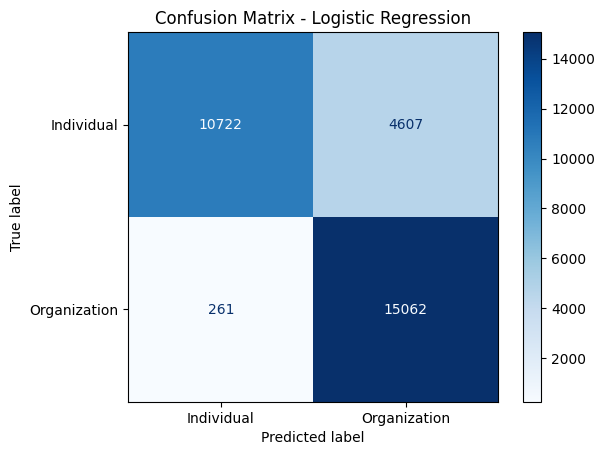

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Confusion matrix
cm = confusion_matrix(y_test, predictions, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Individual', 'Organization'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()